In [1]:
%matplotlib notebook
import ast
import time

import camb
import matplotlib.pyplot as plt
import numpy as np
import sacc
from astropy.io import fits
from camb.correlations import lensed_cl_derivatives

In [2]:
# Read lensing binning matrix

lensing_binning_matrix = np.loadtxt("data/lensing_binning_matrix.txt")
lmax_kk = len(lensing_binning_matrix[0])
nb_bins_kk = len(lensing_binning_matrix)
ell_kk = np.arange(lmax_kk)
ell_kk_center = lensing_binning_matrix.dot(np.arange(lmax_kk))

In [3]:
# Load CMB temperature/polarization data, covariance and bandpowers

s = sacc.Sacc.load_fits("data/data_sacc_w_covar_and_Bbl.fits")

In [4]:
# Extract cosmological parameters, fsky, lmax

fsky = float(s.metadata["f_sky_LAT"])
cosmo = ast.literal_eval(s.metadata["cosmo_params"])
cosmomc_theta = cosmo["cosmomc_theta"]
As = 1e-10 * np.exp(cosmo["logA"])
ombh2 = cosmo["ombh2"]
omch2 = cosmo["omch2"]
ns = cosmo["ns"]
Alens = cosmo["Alens"]
tau = cosmo["tau"]

lmax_CMB = int(s.metadata["lmax"]) + 1
accuracy_dic = ast.literal_eval(s.metadata['accuracy_params'])

In [5]:
# Compute power spectra with CAMB, required to then compute derivatives

pars = camb.set_params(
    ombh2=ombh2,
    omch2=omch2,
    cosmomc_theta=cosmomc_theta,
    tau=tau,
    As=As,
    ns=ns,
    Alens=Alens,
    lmax = lmax_CMB,
    lens_potential_accuracy = accuracy_dic['lens_potential_accuracy'],
    lens_margin = accuracy_dic['lens_margin'],
    AccuracyBoost = accuracy_dic['AccuracyBoost'],
    lSampleBoost = accuracy_dic['lSampleBoost'],
    lAccuracyBoost = accuracy_dic['lAccuracyBoost'],
    kmax = accuracy_dic['kmax'],
    k_per_logint = accuracy_dic['k_per_logint'],
    nonlinear = accuracy_dic['nonlinear'],
    DoLateRadTruncation = accuracy_dic['DoLateRadTruncation'],
)


pars.set_for_lmax(lmax_CMB)
results = camb.get_results(pars)
cls = results.get_unlensed_total_cls(CMB_unit="muK")[0 : lmax_CMB + 1, :]
clp = results.get_lens_potential_cls(CMB_unit="muK")[0 : lmax_CMB + 1, 0]
cl_kk = np.pi / 2 * clp[0:lmax_kk]

In [6]:
# Compute derivatives, takes about 20mn to run

t1 = time.time()
dCllens = lensed_cl_derivatives(cls, clp)
t2 = time.time()
print(t2 - t1)

1089.7823491096497


In [7]:
np.save("products/dCllens.npy", dCllens)

In [8]:
dCllens = np.load("products/dCllens.npy")

In [9]:
# Compute cross-covariance matrix between l(l+1)/(2*pi)C_l^{TT,EE,TE} and C_l^{kk} 
# (no prefactor before C_l^{kk})
# Using the center of CMB lensing bins
     
XCov_binned = np.zeros((s.mean.size, nb_bins_kk))

index_cmb = 0
for comb in s.get_tracer_combinations():
    (t1, t2) = comb
    if t1[-1] == "0" and t2[-1] == "0":
        # TT case
        ind = s.indices("cl_00", comb)
        ind_CAMB = 0
    elif t1[-1] == "2" and t2[-1] == "2":
        # EE case
        ind = s.indices("cl_ee", comb)
        ind_CAMB = 1
    else:
        # TE case
        ind = s.indices("cl_0e", comb)
        ind_CAMB = 3

    bpw = s.get_bandpower_windows(ind)
    w = bpw.weight.T  # Shape (k, ell)
    
    # Precompute XCov with vectorized operations
    XCov = dCllens[ind_CAMB, bpw.values, :lmax_kk] * 2 * cl_kk / (2 * ell_kk + 1) / fsky

    # Vectorize the inner loop
    for j in range(nb_bins_kk):
        w_kk = lensing_binning_matrix[j]
        # Vectorized double sum
        XCov_binned[index_cmb:index_cmb + len(w), j] = w @ np.sum(w_kk * XCov, axis=1)

    index_cmb += len(w)


In [10]:
import copy

Cov_kk = np.loadtxt("data/lensingbinnedcov.txt")

XCorr = copy.deepcopy(XCov_binned)
for k in range(len(XCorr)):
    for j in range(len(XCorr[0])):
        XCorr[k,j] = XCov_binned[k,j]/np.sqrt(Cov_kk[j,j]*s.covariance.covmat[k,k])

<IPython.core.display.Javascript object>


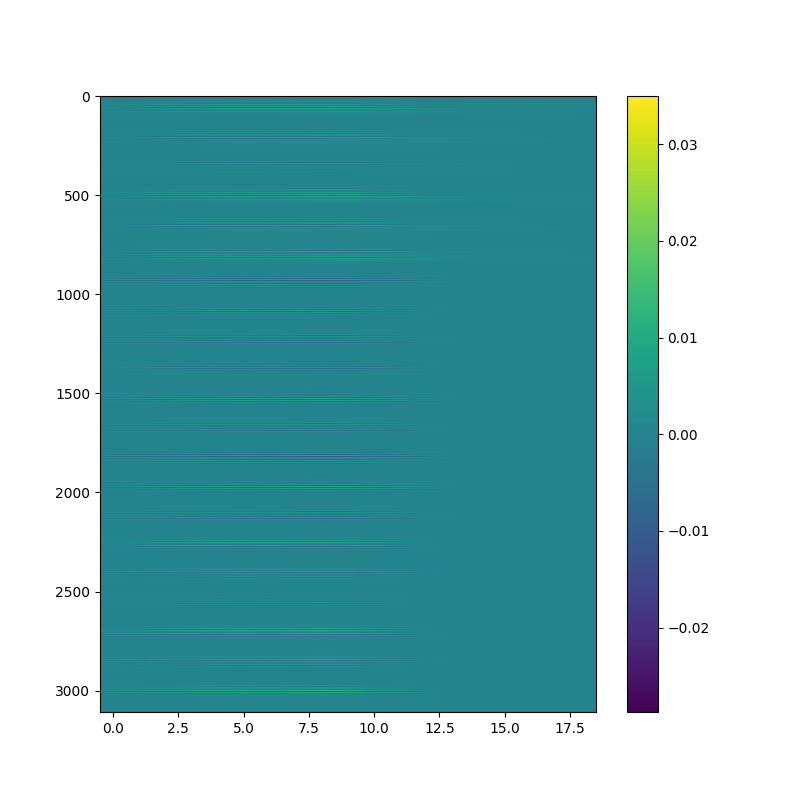

In [11]:
plt.figure(figsize=(8, 8))
plt.imshow(XCorr, aspect="auto")
plt.colorbar()

In [12]:
# Save cross-covariance
np.save('products/XCov.npy', XCov_binned)

# Lensing induced covariance in CMB primary block

In [13]:
# Computes the lensing induced covariance (introduces some mixing between different modes)
# Runs in about 15min

def f_ind_CAMB(comb):
    (t1, t2) = comb
    if t1[-1] == '0' and t2[-1] == '0':
        ind = s.indices('cl_00', comb)
        ind_CAMB = 0
    elif t1[-1] == '2' and t2[-1] == '2':
        ind = s.indices('cl_ee', comb)
        ind_CAMB = 1
    else:
        ind = s.indices('cl_0e', comb)
        ind_CAMB = 3
    return (ind, ind_CAMB)

Lensing_cov = np.zeros((s.mean.size, s.mean.size))
ell3 = np.arange(0, len(clp), 1)
factor = 2 / (2 * ell3 + 1) / fsky

comb = s.get_tracer_combinations()
num_comb = len(comb)

cached_data = [
    (f_ind_CAMB(comb[i]), s.get_bandpower_windows(f_ind_CAMB(comb[i])[0]))
    for i in range(num_comb)
]

time1 = time.time()
for index1 in range(num_comb):
    (ind1, ind_CAMB1), bpw1 = cached_data[index1]
    w1 = bpw1.weight.T
    for index2 in range(index1, num_comb):
        
        (ind2, ind_CAMB2), bpw2 = cached_data[index2]
        w2 = bpw2.weight.T
        
        A1 = w1 @ dCllens[ind_CAMB1, bpw1.values]
        A2 = w2 @ dCllens[ind_CAMB2, bpw2.values]
        product = (A1[:, np.newaxis] * A2[np.newaxis, :]) * factor
        
        Lensing_cov[index1 * len(w1):(index1 + 1) * len(w1),
                    index2 * len(w2):(index2 + 1) * len(w2)] = np.sum(product, axis=2)
time2 = time.time()
print(time2-time1)

804.8101108074188


In [14]:
Lensing_cov_upper_diag = np.triu(Lensing_cov, 0)
Lensing_cov_upper = np.triu(Lensing_cov, 1)
Lensing_cov_full = Lensing_cov_upper_diag + Lensing_cov_upper.T

In [15]:
# Save lensing induced covariance
np.save('products/Lensing_cov.npy', Lensing_cov_full)

In [16]:
import copy

XCorr = copy.deepcopy(Lensing_cov_full)
for k in range(len(XCorr)):
    for j in range(len(XCorr[0])):
        XCorr[k,j] = Lensing_cov_full[k,j]/np.sqrt(s.covariance.covmat[j,j]*s.covariance.covmat[k,k])

<IPython.core.display.Javascript object>


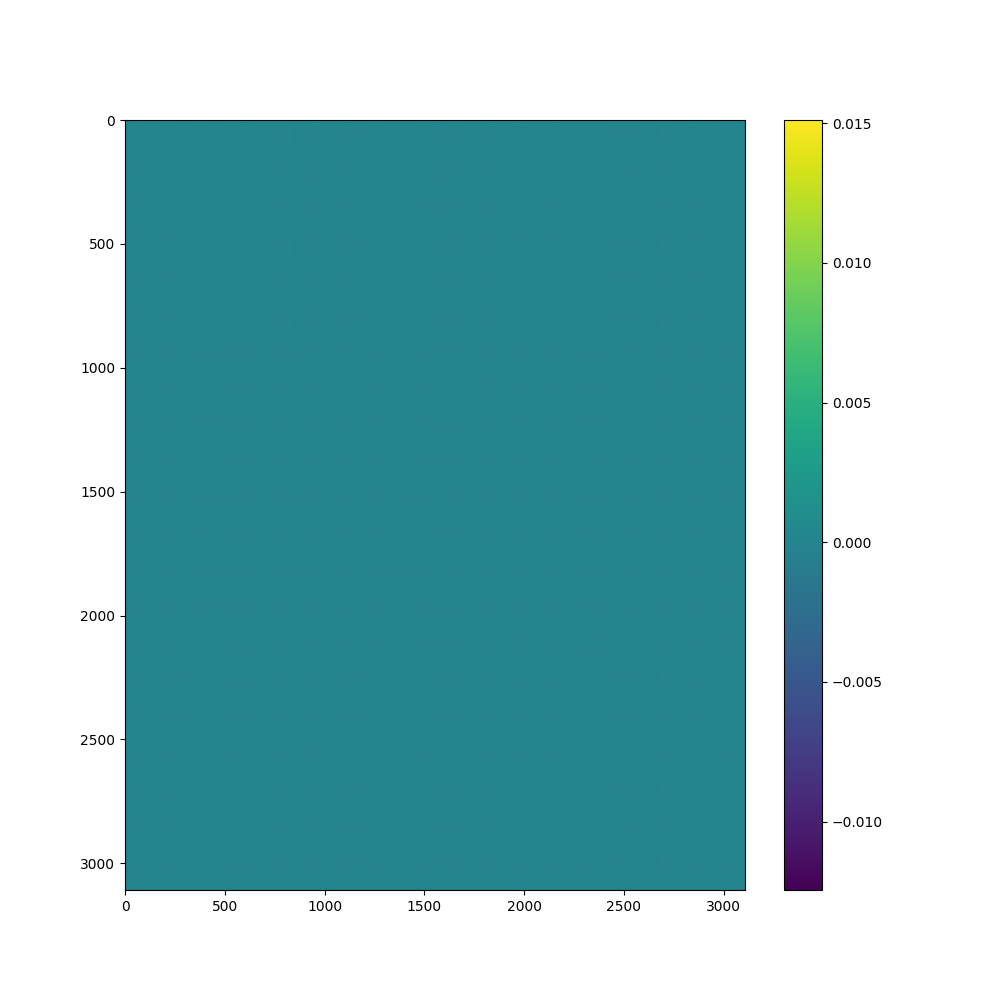

In [17]:
plt.figure(figsize=(10,10))
plt.imshow(XCorr, aspect='auto')
plt.colorbar()

# Test impact of N1 bias on the cross-covariance

In [18]:
# Computes the N1 bias curve. Warning: this cell is very long (almost 1h)
import imp
import lensitbiases
import lensitbiases as lb
from lensitbiases import n0_fft, n1_fft, utils_n1
from scipy import signal
from scipy.interpolate import InterpolatedUnivariateSpline as spline
from scipy.interpolate import UnivariateSpline as spl


lminbox=20
cls_unl, cls_len, cls_grad = lb.get_default_cls() 

estimator = 'p'


nTf = np.loadtxt('data/SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_CMB.txt')
nPf = np.loadtxt('data/SO_LAT_Nell_P_baseline_fsky0p4_ILC_CMB_E.txt')
nlevT = (np.sqrt(np.concatenate((np.zeros(40),nTf[:,1]))) *60 * 180/np.pi)[:4000+1]
nlevP = (np.sqrt(np.concatenate((np.zeros(40),nPf[:,1]))) *60 * 180/np.pi)[:4000+1]

fal = utils_n1.get_fal(clscmb_filt=cls_len, clscmb_dat=cls_len, beam=0,
                   lmin_ivf=100, lmax_ivf=4000, nlevt=nlevT, nlevp=nlevP, jt_tp=False)[1]

lib_n1 = n1_fft.n1_fft(fal, cls_len, cls_grad, cls_unl['pp'], lminbox=lminbox, lmaxbox=2500*2) 

Ls_n1 = np.arange(lminbox, 4000+1, 1, dtype=np.int64) #np.linspace(lminbox, 2*2048, 10)
    
res = [lib_n1.get_n1(estimator, L, do_n1mat=True) for L in Ls_n1]

n1_SOlike = np.array([r[0] for r in res])
n1_mat = np.array([r[1] for r in res]) 

# the normalization should be the same as the one used in ones' analysis. Here's one way to get it with this package
(R_gg, R_cc), Ls_r = n0_fft.nhl_fft(fal, cls_grad, lminbox=lminbox, lmaxbox=5000).get_nhl(estimator)  # gradient and curl responses, and multipoles
normalization = 1/spl(Ls_r, R_gg, k=2, s=0, ext='zeros')(Ls_n1) ** 2

In [19]:
def gaussian_smooth_1d(data, sigma, nsigma=5):
    win = signal.gaussian(nsigma * sigma, std=sigma)
    res = np.convolve(data, win, mode='same')
    return res / np.convolve(np.ones(data.shape), win, mode='same')

a=np.arange(n1_mat.shape[1], dtype=np.int64)
nonzero =a[n1_mat[62,:]!=0]
diffs = np.concatenate(([10],(nonzero[2:] - nonzero[:-2])/2,[10]))
scaled = n1_mat.copy()
scaled[:,nonzero] = n1_mat[:,nonzero]/diffs
sc = clp[:n1_mat.shape[1]]/(a*(a+1))**2  # use lensing to rescale before smoothing, then divide out
sc[:2]=1
N1_mat_smoothed = scaled.copy()
for i, L in enumerate(Ls_n1):
    N1_mat_smoothed[i,:] = spline(nonzero, gaussian_smooth_1d(scaled[i,nonzero]*sc[nonzero],20))(a)/sc


<ipython-input-19-3a7b78bb005f>:11: RuntimeWarning: invalid value encountered in divide
  sc = clp[:n1_mat.shape[1]]/(a*(a+1))**2  # use lensing to rescale before smoothing, then divide out


In [20]:
fac = (a*(a+1))**2/2/np.pi
fac[0]=1
minl = min(n1_mat.shape[1], cls_unl['pp'].shape[0])

# define n1_normed_mat_smoothed which acts on and returns [L(L+1)]^2/2-like quantities

n1_normed_mat_smoothed = fac[Ls_n1,np.newaxis]*normalization[:,np.newaxis]*N1_mat_smoothed / fac

In [21]:
np.save("products/n1_normed_mat_smoothed.npy", n1_normed_mat_smoothed)

In [22]:
n1_normed_mat_smoothed = np.load("products/n1_normed_mat_smoothed.npy")

In [23]:
def f_ind_CAMB(comb):
    (t1, t2) = comb
    if t1[-1] == '0' and t2[-1] == '0':
        ind = s.indices('cl_00', comb)
        ind_CAMB = 0
    elif t1[-1] == '2' and t2[-1] == '2':
        ind = s.indices('cl_ee', comb)
        ind_CAMB = 1
    else:
        ind = s.indices('cl_0e', comb)
        ind_CAMB = 3
    return (ind, ind_CAMB)

XCov_N1 = np.zeros((s.mean.size,nb_bins_kk))
ell3 = np.arange(0, n1_normed_mat_smoothed.shape[1], 1)
factor = 2 * clp[0:n1_normed_mat_smoothed.shape[1]] / (2 * ell3 + 1) / fsky
factor[1:] *= (2*np.pi) / (ell3[1:]*(ell3[1:]+1))**2

comb = s.get_tracer_combinations()
num_comb = len(comb)

cached_data = [
    (f_ind_CAMB(comb[i]), s.get_bandpower_windows(f_ind_CAMB(comb[i])[0]))
    for i in range(num_comb)
]

time1 = time.time()
for index1 in range(num_comb):
    (ind1, ind_CAMB1), bpw1 = cached_data[index1]
    w1 = bpw1.weight.T

    A1 = w1 @ dCllens[ind_CAMB1, bpw1.values]
    A2 = lensing_binning_matrix @ n1_normed_mat_smoothed[0:lmax_kk,:]*np.pi/2.
    product = (A1[:, np.newaxis, 0:n1_normed_mat_smoothed.shape[1]] * A2[np.newaxis, :]) * factor

    XCov_N1[index1 * len(w1):(index1 + 1) * len(w1),:] = np.sum(product, axis=2)
time2 = time.time()
print(time2-time1)

27.56715226173401


In [24]:
np.save('products/XCov_N1.npy', XCov_N1)

<IPython.core.display.Javascript object>


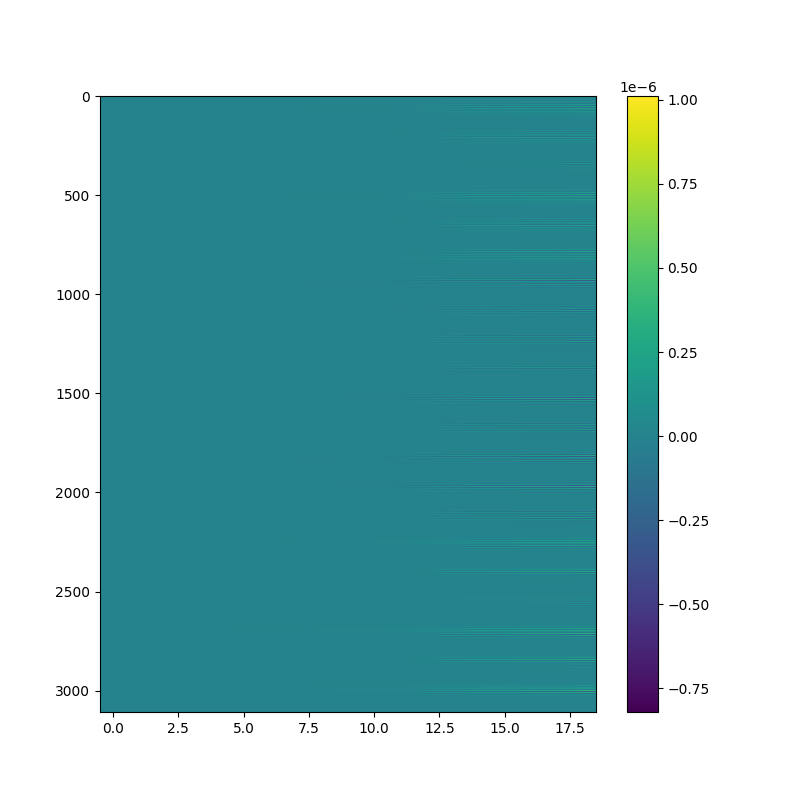

In [25]:
# Plot correlation cross-covariance due to N1
XCorr = copy.deepcopy(XCov_N1)
for k in range(len(XCorr)):
    for j in range(len(XCorr[0])):
        XCorr[k,j] = XCov_N1[k,j]/np.sqrt(Cov_kk[j,j]*s.covariance.covmat[k,k])
plt.figure(figsize=(8,8))
plt.imshow(XCorr, aspect='auto')
plt.colorbar()